# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

In [3]:
data_base_path = "./asl_data/"

### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [4]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [5]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

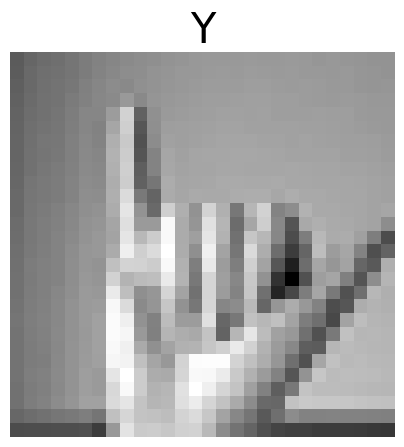

In [6]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [7]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [8]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [9]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [10]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [11]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [12]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [13]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [14]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [01:23<00:00,  4.19s/epoch, train_acc=0.8841, train_loss=0.3331, val_acc=0.7685, val_loss=0.8180]


In [15]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [16]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [17]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [05:25<00:00, 16.29s/epoch, train_acc=0.9972, train_loss=0.0099, val_acc=0.9523, val_loss=0.2249]


In [18]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

## Reflection section

### Which model is better at classifying ASL images?

In [19]:
print(f"FCNN Test Loss: {fcnn_test_loss:.4f}, FCNN Test Accuracy: {fcnn_test_acc:.4f}")
print(f"CNN Test Loss: {cnn_test_loss:.4f}, CNN Test Accuracy: {cnn_test_acc:.4f}")

FCNN Test Loss: 0.8288, FCNN Test Accuracy: 0.7680
CNN Test Loss: 0.1916, CNN Test Accuracy: 0.9587


The CNN model is better at classifying ASL images based on the evaluation using the test set. First, the FCNN only approaches a value of 0.77, while the CNN model shows a big difference by increasing the accuracy to 0.96.

### Which model was _faster_ to train?

The FCNN model was significantly faster to train. It took 1 minute and 26 seconds using the CPU, whereas the CNN model took 5 minutes and 25 seconds.

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

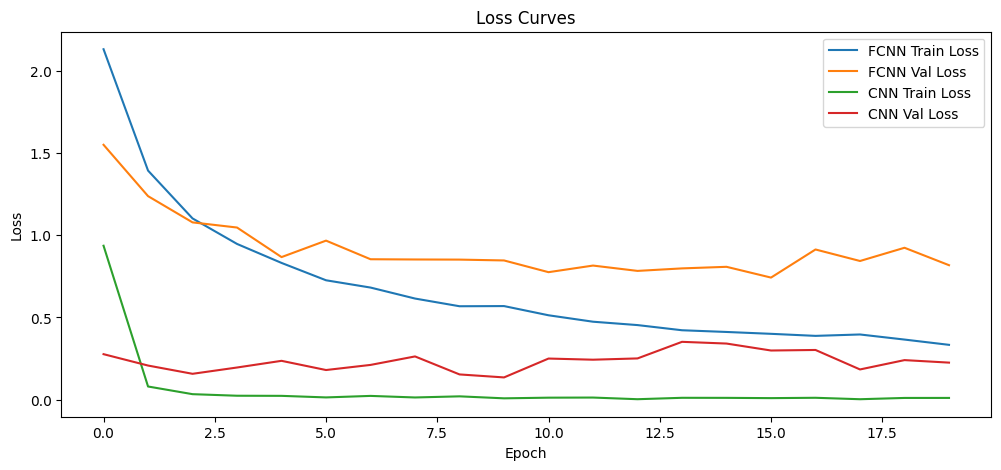

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(fcnn_res['train_loss'], label='FCNN Train Loss')
plt.plot(fcnn_res['val_loss'], label='FCNN Val Loss')
plt.plot(cnn_res['train_loss'], label='CNN Train Loss')
plt.plot(cnn_res['val_loss'], label='CNN Val Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

The CNN demonstrates a clear improvement in performance. As seen in the graph, both the training and validation loss curves for the CNN are consistently lower than those of the FCNN. However, it is important to note that both models show signs of overfitting. As the epochs advance, the training loss continues to decrease while the validation loss starts to increase, which is an indicator of overfitting.

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

In [21]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512), # 784 x 512 + 512 = 401,920
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512), # 512 x 512 + 512 = 262,656
    nn.ReLU(),
    nn.Linear(512, 24) # 512 x 24 + 24 = 12,312
)

model_fcnn = model_fcnn.to(device)

FCNN: 401,920 + 262,656 + 12,312 = 676,888

In [22]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1), # 25 x (1 x 3 x 3 + 1) = 250
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), 

    nn.Conv2d(25, 50, 3, stride=1, padding=1), # 50 x (25 x 3 x 3 + 1) = 11,300
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2), 

    nn.Conv2d(50, 75, 3, stride=1, padding=1), # 75 x (50 x 3 x 3 + 1) = 33,825
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), 

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512), # 675 x 512 + 512 = 346,112
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24) # 512 x 24 + 24 = 12,312
)

model_cnn = model_cnn.to(device)

CNN: 250 + 11,300 + 33,825 + 346,112 + 12,312 = 403,799

### How do the models compare in terms of overfitting? Why do you think that is the case?

Both models show signs of overfitting, as the training loss continues to decrease while the validation loss starts to slightly increase. However, the FCNN model overfits much more than the CNN model. The gap between the training loss and the validation loss is considerably larger in the FCNN compared to the CNN.

### Final conclusions and remarks

We can conclude that the CNN was a better model in comparison to the FCNN for image classification. However, there is a disadvantage with this because we need more resources to run the CNN, most of the time it is recommended to use a GPU in these tasks due to the time it takes to train these models. Besides this, it gives you great results depending on the model that you build. For example, the CNN model achieved great results, but there were signs of overfitting, so we need to take care of that during training to obtain the best results. On the other hand, the number of parameters was reduced depending on the model. In the FCNN we have a lot of parameters to train, leading to overfitting, but in the CNN we have 403,799. So, having a lot of parameters probably leads to overfitting due to memorization, as seen in the FCNN. The CNN reduces the number of parameters, achieving better learning.